# Phase 1 - Multilingual Graph Prototype
This notebook builds the backbone of the graph engine, discovering all lexicon resources, supporting multiple languages.

## Setup
Import necessary libraries and configure parameters.

In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import os
import glob

plt.rcParams['figure.figsize'] = (10, 8)


## Discover input files
Detect which CSVs are available for semantic and abugida data.

In [4]:
input_dir = 'data/'
resources = {
    'semantic': {
        'lexicons': {},
        'concept_domain': None,
        'synset_mapping': None
    },
    'abugida': {}
}

def get_lang_code(filename):
    filename = filename.lower()
    if 'nepali' in filename or '_np' in filename: return 'np'
    if 'darija' in filename or '_dr' in filename: return 'dr'
    if 'urdu' in filename or '_ur' in filename: return 'ur'
    if 'vietnamese' in filename or 'viet' in filename or '_vn' in filename: return 'vn'
    return 'unknown'

for file in glob.glob(os.path.join(input_dir, '*.csv')) + glob.glob(os.path.join(input_dir, '*.tsv')):
    filename = os.path.basename(file)
    lower_name = filename.lower()
    if 'concept_domain' in lower_name:
        resources['semantic']['concept_domain'] = filename
    elif 'ukc_wn30_mappings' in lower_name:
        resources['semantic']['synset_mapping'] = filename
    elif 'abugida' in lower_name:
        lang = get_lang_code(lower_name)
        resources['abugida'][lang] = filename
    elif 'lexicon' in lower_name:
        lang = get_lang_code(lower_name)
        resources['semantic']['lexicons'][lang] = filename

print("Discovered Resources:", resources)

Discovered Resources: {'semantic': {'lexicons': {'np': 'nepali_english_ukc_lexicon_transliterated.csv', 'vn': 'vietnamese_english_ukc_lexicon.csv', 'ur': 'urdu_english_ukc_lexicon.csv', 'dr': 'darija_english_ukc_lexicon.csv'}, 'concept_domain': 'concept_domain.csv', 'synset_mapping': 'ukc_wn30_mappings (1).tsv'}, 'abugida': {'np': 'nepali_abugida_data.csv'}}


## Load and normalize semantic resources
Helper functions to keep everything clean and case-insensitive.

In [5]:
def normalize_columns(df):
    df.columns = [str(col).strip().lower() for col in df.columns]
    return df

def safe_text(value):
    if pd.isna(value):
        return ""
    return str(value).strip()

def make_node_id(node_type, *parts):
    clean_parts = [str(p).strip() for p in parts if str(p).strip()]
    return f"{node_type}:" + ":".join(clean_parts)

def add_node_if_missing(G, node_id, **attrs):
    if node_id and not G.has_node(node_id):
        G.add_node(node_id, **attrs)

def add_edge_if_missing(G, source, target, relation, **attrs):
    if source and target:
        if not G.has_edge(source, target):
            G.add_edge(source, target, relation=relation, **attrs)

## Build semantic graph (Pass 1)
Load the concepts from all sources, attaching domains and synsets.

In [7]:
G = nx.DiGraph()

if resources['semantic']['concept_domain']:
    domain_df = pd.read_csv(resources['semantic']['concept_domain'])
    domain_df = normalize_columns(domain_df)
    for _, row in domain_df.iterrows():
        concept_id = safe_text(row.get('concept_id'))
        if not concept_id: continue
        c_node = make_node_id('concept', concept_id)
        add_node_if_missing(G, c_node, type='Concept', concept_id=concept_id)
        
        wn30_id = safe_text(row.get('wn30_id'))
        if wn30_id:
            s_node = make_node_id('synset', wn30_id)
            add_node_if_missing(G, s_node, type='Synset', wn30_id=wn30_id)
            add_edge_if_missing(G, c_node, s_node, relation='mapped_to_synset')
            
        domain = safe_text(row.get('domain'))
        if domain:
            d_node = make_node_id('domain', domain)
            add_node_if_missing(G, d_node, type='Domain', domain=domain)
            add_edge_if_missing(G, c_node, d_node, relation='belongs_to_domain')

for lang, filename in resources['semantic']['lexicons'].items():
    lex_df = pd.read_csv(filename)
    lex_df = normalize_columns(lex_df)
    for _, row in lex_df.iterrows():
        concept_id = safe_text(row.get('concept_id'))
        if not concept_id: continue
        c_node = make_node_id('concept', concept_id)
        add_node_if_missing(G, c_node, type='Concept', concept_id=concept_id)

print(f"Total nodes after pass 1: {G.number_of_nodes()}")

FileNotFoundError: [Errno 2] No such file or directory: 'concept_domain.csv'

## Build semantic graph (Pass 2)
Add lemmas (English, Target Language, and Romanized) and link them to concepts.

In [21]:
for lang, filename in resources['semantic']['lexicons'].items():
    lex_df = pd.read_csv(filename)
    lex_df = normalize_columns(lex_df)
    for _, row in lex_df.iterrows():
        concept_id = safe_text(row.get('concept_id'))
        if not concept_id: continue
        c_node = make_node_id('concept', concept_id)
        
        eng_lemmas = safe_text(row.get('english_lemmas')).split('|')
        for lemma in eng_lemmas:
            lemma = lemma.strip()
            if lemma:
                e_node = make_node_id('lemma', 'eng', lemma)
                add_node_if_missing(G, e_node, type='Lemma-eng', language='eng', text=lemma)
                add_edge_if_missing(G, e_node, c_node, relation='english_label_for')
        
        lang_lemmas = [l.strip() for l in safe_text(row.get('lemmas')).split('|') if l.strip()]
        roman_lemmas = [l.strip() for l in safe_text(row.get('transliterated form')).split('|') if l.strip()]
        for i, lemma in enumerate(lang_lemmas):
            l_node = make_node_id('lemma', lang, lemma)
            add_node_if_missing(G, l_node, type='Lemma-lang', language=lang, text=lemma)
            add_edge_if_missing(G, l_node, c_node, relation='target_label_for')
            
            if len(lang_lemmas) == len(roman_lemmas):
                r_lemma = roman_lemmas[i]
                if r_lemma:
                    r_node = make_node_id('roman', lang, r_lemma)
                    add_node_if_missing(G, r_node, type='Lemma-roman', language=lang, text=r_lemma)
                    add_edge_if_missing(G, l_node, r_node, relation='romanised_as')

print(f"Total nodes after pass 2: {G.number_of_nodes()}")
print(f"Total edges after pass 2: {G.number_of_edges()}")

Total nodes after pass 2: 289651
Total edges after pass 2: 306252


## Visualize graph checkpoints (Semantic Layer)
Visualizing the semantic layer with its edges.

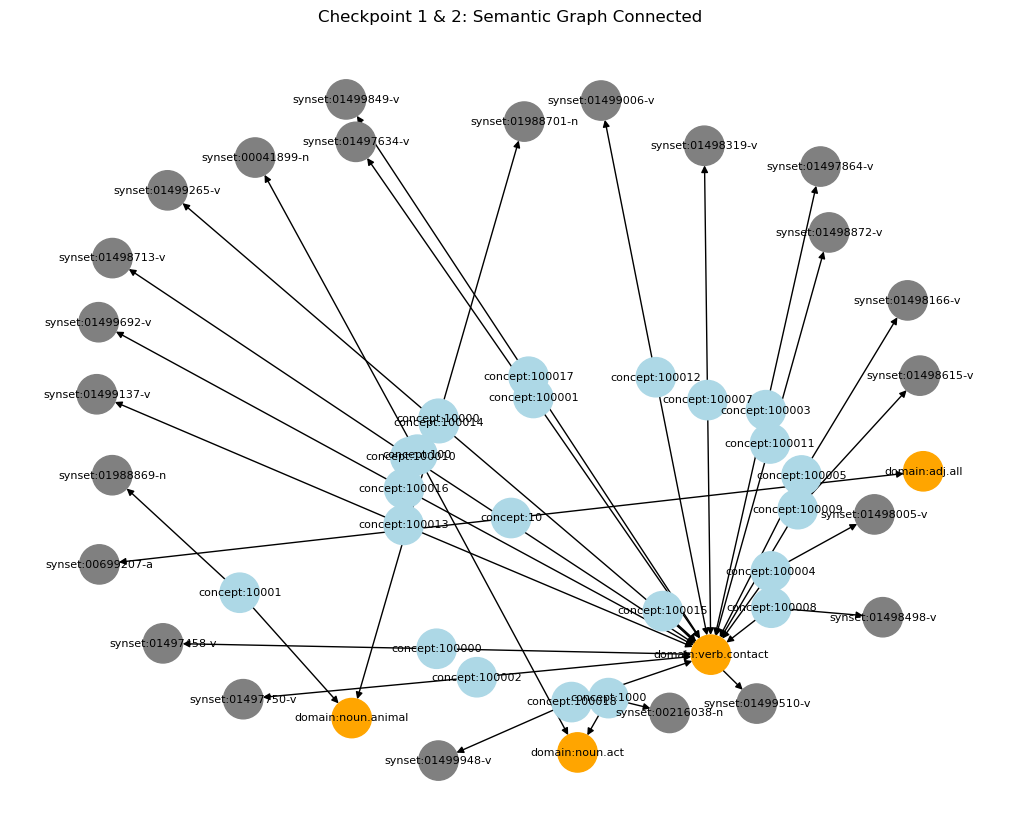

In [23]:
def visualize_sample(G, title, sample_size=50):
    if G.number_of_nodes() == 0:
        print("Graph is empty.")
        return
    sub_nodes = list(G.nodes())[:sample_size]
    subG = G.subgraph(sub_nodes)
    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(subG, seed=42)
    color_map = []
    for node in subG.nodes():
        t = subG.nodes[node].get('type', '')
        if t == 'Concept': color_map.append('lightblue')
        elif t == 'Lemma-eng': color_map.append('lightgreen')
        elif t == 'Lemma-lang': color_map.append('lightcoral')
        elif t == 'Domain': color_map.append('orange')
        else: color_map.append('gray')
    nx.draw(subG, pos, with_labels=True, node_color=color_map, node_size=800, font_size=8)
    plt.title(title)
    plt.show()

visualize_sample(G, "Checkpoint 1 & 2: Semantic Graph Connected")

## Attach optional abugida layers
Connect the phoneme/grapheme data when it exists. We maintain a distinct `Lemma-roman-abugida` for transliteration.

In [24]:
def attach_abugida_layer(G, lang, csv_path):
    if not os.path.exists(csv_path):
        print(f"Skipping: {csv_path} not found.")
        return
    df = pd.read_csv(csv_path)
    df = normalize_columns(df)
    nodes_added = 0
    edges_added = 0
    for _, row in df.iterrows():
        char = safe_text(row.get('character'))
        if not char: continue
        g_node = make_node_id('grapheme', lang, char)
        add_node_if_missing(G, g_node, type='Grapheme', language=lang, char=char)
        nodes_added += 1
        
        ipa = safe_text(row.get('ipa'))
        p_node = None
        if ipa:
            p_node = make_node_id('phoneme', lang, ipa)
            add_node_if_missing(G, p_node, type='Phoneme', language=lang, ipa=ipa)
            add_edge_if_missing(G, p_node, g_node, relation='phoneme_written_as')
            nodes_added += 1
            edges_added += 1
            
        trans = safe_text(row.get('transliteration'))
        if trans and p_node:
            r_node = make_node_id('abugida_roman', lang, trans)
            add_node_if_missing(G, r_node, type='Lemma-roman-abugida', language=lang, text=trans)
            add_edge_if_missing(G, p_node, r_node, relation='phoneme_transliterated_as')
            nodes_added += 1
            edges_added += 1
            
        audio = safe_text(row.get('audio')) or safe_text(row.get('audio_path'))
        if audio and p_node:
            a_node = make_node_id('audio', lang, audio)
            add_node_if_missing(G, a_node, type='Audio', language=lang, audio_path=audio)
            add_edge_if_missing(G, a_node, p_node, relation='audio_represents')
            nodes_added += 1
            edges_added += 1
            
    print(f"Attached abugida layer {lang}: ~{nodes_added} nodes, {edges_added} edges.")

for lang, filepath in resources['abugida'].items():
    attach_abugida_layer(G, lang, filepath)

Attached abugida layer np: ~212 nodes, 159 edges.


## Visualize graph checkpoints (Abugida)
Visualizing the abugida subgraph.

/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2324 (\N{DEVANAGARI LETTER AU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2313 (\N{DEVANAGARI LETTER U}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2310 (\N{DEVANAGARI LETTER AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2320 (\N{DEVANAGARI LETTER AI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)

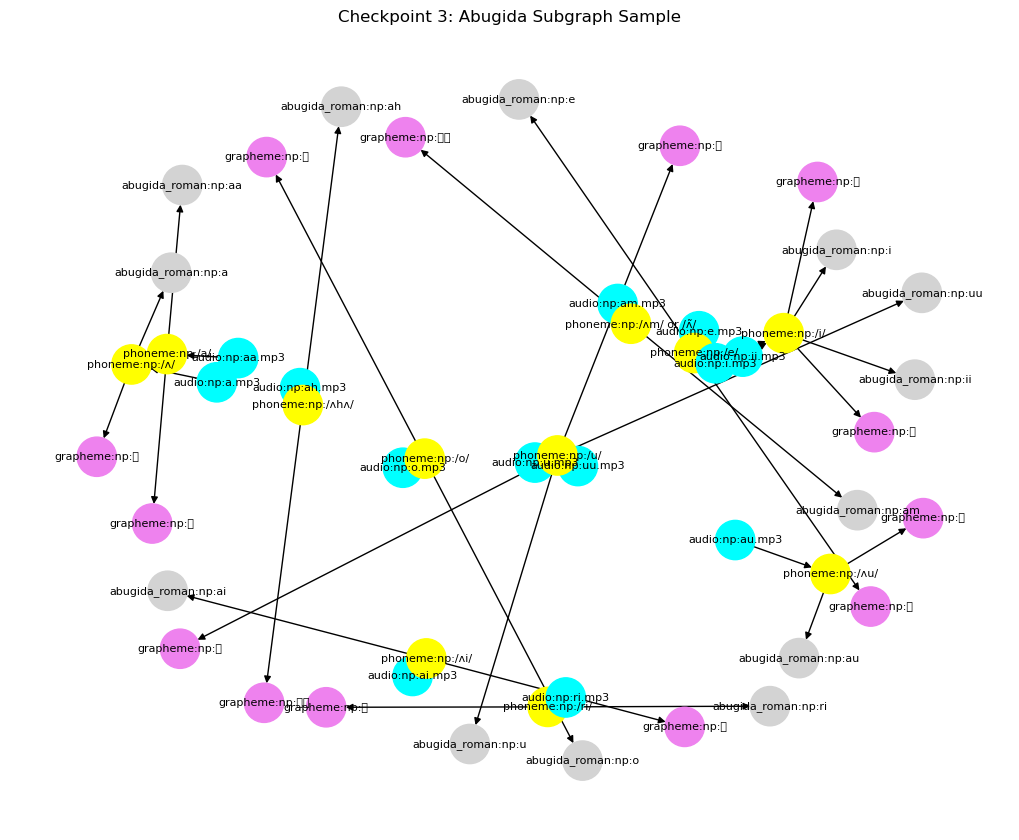

In [25]:
abugida_nodes = [n for n in G.nodes() if G.nodes[n].get('type') in ['Grapheme', 'Phoneme', 'Audio', 'Lemma-roman-abugida']]
if abugida_nodes:
    subG_abugida = G.subgraph(abugida_nodes[:50])
    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(subG_abugida, seed=42)
    color_map = []
    for node in subG_abugida.nodes():
        t = subG_abugida.nodes[node].get('type', '')
        if t == 'Grapheme': color_map.append('violet')
        elif t == 'Phoneme': color_map.append('yellow')
        elif t == 'Audio': color_map.append('cyan')
        else: color_map.append('lightgray')
    nx.draw(subG_abugida, pos, with_labels=True, node_color=color_map, node_size=800, font_size=8)
    plt.title("Checkpoint 3: Abugida Subgraph Sample")
    plt.show()
else:
    print("No abugida nodes available to visualize.")

## Export graph artifacts
Export the graphml, nodes.csv, and edges.csv.

In [26]:
nodes_data = []
for node, data in G.nodes(data=True):
    row = {'id': node}
    row.update(data)
    nodes_data.append(row)
pd.DataFrame(nodes_data).to_csv('nodes.csv', index=False)

edges_data = []
for u, v, data in G.edges(data=True):
    row = {'source': u, 'target': v}
    row.update(data)
    edges_data.append(row)
pd.DataFrame(edges_data).to_csv('edges.csv', index=False)

nx.write_graphml(G, 'graph.graphml')
print("Exported graph.graphml, nodes.csv, and edges.csv.")

Exported graph.graphml, nodes.csv, and edges.csv.


## Validate graph
Validate sizes, relations, and flag warnings for incomplete components.

In [27]:
print("=== Validation Summary ===")
print(f"Total Nodes: {G.number_of_nodes()}")
node_types = {}
for n, d in G.nodes(data=True):
    t = d.get('type', 'Unknown')
    node_types[t] = node_types.get(t, 0) + 1
for t, count in node_types.items():
    print(f"  {t}: {count}")

print(f"\nTotal Edges: {G.number_of_edges()}")
edge_relations = {}
for u, v, d in G.edges(data=True):
    r = d.get('relation', 'Unknown')
    edge_relations[r] = edge_relations.get(r, 0) + 1
for r, count in edge_relations.items():
    print(f"  {r}: {count}")

components = list(nx.weakly_connected_components(G))
print(f"\nConnected Components (Weak): {len(components)}")

# Checks
eng_lemmas = [n for n, d in G.nodes(data=True) if d.get('type') == 'Lemma-eng']
lang_lemmas = [n for n, d in G.nodes(data=True) if d.get('type') == 'Lemma-lang']
domains = [n for n, d in G.nodes(data=True) if d.get('type') == 'Domain']

eng_unlinked = sum(1 for n in eng_lemmas if G.out_degree(n) == 0 and G.in_degree(n) == 0)
lang_unlinked = sum(1 for n in lang_lemmas if G.out_degree(n) == 0 and G.in_degree(n) == 0)
domain_unlinked = sum(1 for n in domains if G.in_degree(n) == 0)

if eng_unlinked > 0: print(f"WARNING: {eng_unlinked} Lemma-eng nodes unlinked.")
if lang_unlinked > 0: print(f"WARNING: {lang_unlinked} Lemma-lang nodes unlinked.")
if domain_unlinked > 0: print(f"WARNING: {domain_unlinked} Domain nodes unlinked.")

if not resources['abugida']:
    print("Notice: No abugida resources attached.")
else:
    audio_edges = sum(1 for _, _, d in G.edges(data=True) if d.get('relation') == 'audio_represents')
    if audio_edges == 0:
        print("WARNING: Abugida resource provided, but no 'audio_represents' paths found.")


=== Validation Summary ===
Total Nodes: 289854
  Concept: 108719
  Synset: 108569
  Domain: 45
  Lemma-eng: 22104
  Lemma-lang: 37800
  Lemma-roman: 12414
  Grapheme: 53
  Phoneme: 49
  Lemma-roman-abugida: 48
  Audio: 53

Total Edges: 306411
  mapped_to_synset: 108569
  belongs_to_domain: 108569
  english_label_for: 28152
  target_label_for: 48109
  romanised_as: 12853
  phoneme_written_as: 53
  phoneme_transliterated_as: 53
  audio_represents: 53

Connected Components (Weak): 91
